In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, set_seed

# Check GPU availability
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Set seed for reproducibility
set_seed(42)

# Configuration
MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 2


CUDA available: True
GPU: Tesla T4


In [ ]:
# Load SST-2 dataset
dataset = load_dataset("stanfordnlp/sst2")
print("Dataset structure:")
print(dataset)
print("\nExample from training set:")
print(dataset["train"][0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Example from training set:
{'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


--- Label Distribution Summary ---
Total samples: 67349
Negative (0): 29780 (44.2%)
Positive (1): 37569 (55.8%)
Imbalance Ratio (Majority/Minority): 1.26:1
Majority-Class Baseline Accuracy: 55.8%

Justification: Given the relatively low imbalance (ratio < 1.5), accuracy is a suitable primary evaluation metric.


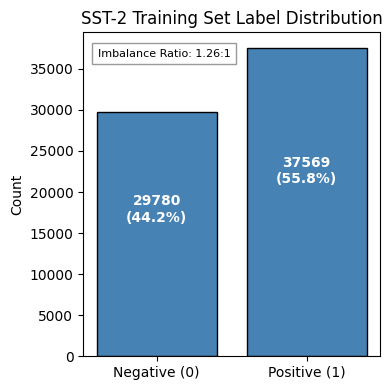

In [ ]:
# Analyze label distribution
train_labels = [ex["label"] for ex in dataset["train"]]
label_counts = Counter(train_labels)
total_samples = sum(label_counts.values())

neg_count = label_counts[0]
pos_count = label_counts[1]
neg_percent = (neg_count / total_samples) * 100
pos_percent = (pos_count / total_samples) * 100

# Calculate imbalance ratio
imbalance_ratio = max(neg_count, pos_count) / min(neg_count, pos_count)
majority_class_baseline = (max(neg_count, pos_count) / total_samples) * 100

# Print summary
print("--- Label Distribution Summary ---")
print(f"Total samples: {total_samples}")
print(f"Negative (0): {neg_count} ({neg_percent:.1f}%)")
print(f"Positive (1): {pos_count} ({pos_percent:.1f}%)")
print(f"Imbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}:1")
print(f"Majority-Class Baseline Accuracy: {majority_class_baseline:.1f}%")
print("\nJustification: Given the relatively low imbalance (ratio < 1.5), accuracy is a suitable primary evaluation metric.")

# Visualize label distribution
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["Negative (0)", "Positive (1)"], [neg_count, pos_count], color="steelblue", edgecolor="black")
ax.set_title("SST-2 Training Set Label Distribution")
ax.set_ylabel("Count")

# Add count and percentage labels on bars
for i, (count, percent) in enumerate([(neg_count, neg_percent), (pos_count, pos_percent)]):
    ax.text(i, count * 0.6, f"{count}\n({percent:.1f}%)", ha="center", va="center", color="white", fontweight="bold")

# Add imbalance ratio annotation
ax.text(0.05, 0.95, f"Imbalance Ratio: {imbalance_ratio:.2f}:1",
        transform=ax.transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
        verticalalignment='top', horizontalalignment='left')

plt.tight_layout()
plt.savefig("sst2_label_distribution.png", dpi=150)
plt.show()


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


--- Sentence Length Statistics ---
Min length: 3 tokens
Max length: 62 tokens
Mean length: 12.5 tokens
95th percentile: 31.0 tokens
Selected max_length: 128 tokens


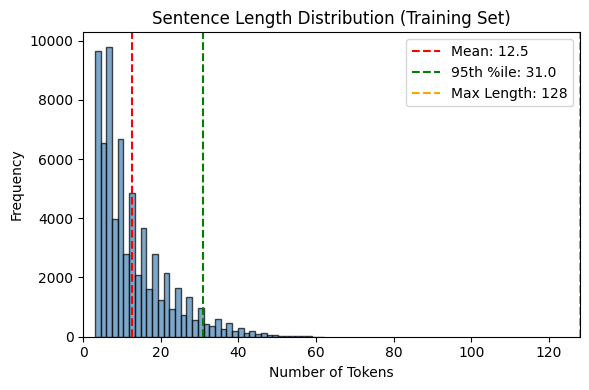

In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Compute tokenized lengths for training set
tokenized_lengths = [
    len(tokenizer.encode(ex["sentence"], add_special_tokens=True))
    for ex in dataset["train"]
]

# Compute statistics
mean_length = np.mean(tokenized_lengths)
percentile_95 = np.percentile(tokenized_lengths, 95)
min_length = np.min(tokenized_lengths)
max_length = np.max(tokenized_lengths)

print("--- Sentence Length Statistics ---")
print(f"Min length: {min_length} tokens")
print(f"Max length: {max_length} tokens")
print(f"Mean length: {mean_length:.1f} tokens")
print(f"95th percentile: {percentile_95:.1f} tokens")
print(f"Selected max_length: {MAX_LENGTH} tokens")

# Visualize sentence length distribution
plt.figure(figsize=(6, 4))
plt.hist(tokenized_lengths, bins=40, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Sentence Length Distribution (Training Set)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.xlim(0, MAX_LENGTH)

# Add reference lines
plt.axvline(mean_length, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_length:.1f}')
plt.axvline(percentile_95, color='green', linestyle='--', linewidth=1.5, label=f'95th %ile: {percentile_95:.1f}')
plt.axvline(MAX_LENGTH, color='orange', linestyle='--', linewidth=1.5, label=f'Max Length: {MAX_LENGTH}')

plt.legend()
plt.tight_layout()
plt.savefig("sst2_length_distribution.png", dpi=150)
plt.show()


In [ ]:
# Load pre-trained model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
print(f"Model loaded: {MODEL_NAME}")

# Define preprocessing function
def preprocess_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

# Tokenize all splits
print("Tokenizing dataset...")
tokenized_dataset = dataset.map(preprocess_function, batched=True, desc="Tokenizing")
tokenized_dataset = tokenized_dataset.remove_columns(["sentence", "idx"])
tokenized_dataset.set_format("torch")
print("Tokenization complete.")


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: microsoft/deberta-v3-small
Tokenizing dataset...


Tokenizing:   0%|          | 0/67349 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/872 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1821 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# Define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./deberta-v3-small-sst2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    fp16=True,
    report_to="none",
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

# Train model
print("Starting training...")
train_output = trainer.train()
print("Training complete.")


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.152300,0.210075,0.944954,0.944907,0.945020,0.944944
2,0.104200,0.242563,0.938073,0.938442,0.937842,0.938018


Training complete.


In [ ]:
# Evaluate on validation set
print("Evaluating on validation set...")
val_results = trainer.evaluate(tokenized_dataset["validation"])

# Extract and print metrics
accuracy = val_results["eval_accuracy"]
precision = val_results["eval_precision"]
recall = val_results["eval_recall"]
f1 = val_results["eval_f1"]

print("\n--- Validation Results ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Evaluating on validation set...



--- Validation Results ---
Accuracy:  0.9450
Precision: 0.9449
Recall:    0.9450
F1-score:  0.9449


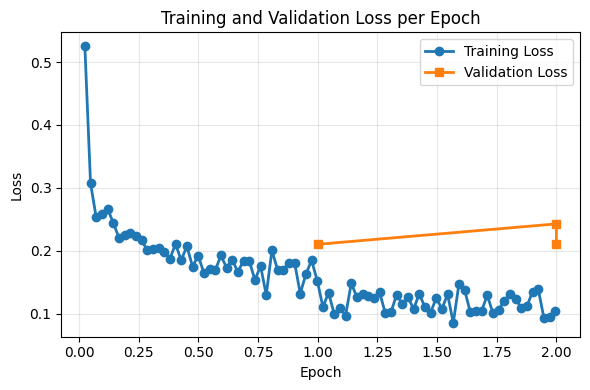

Loss curve saved as loss_curve.png


In [ ]:
# Extract loss history from trainer
train_losses = []
eval_losses = []
steps = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_losses.append(log["loss"])
        steps.append(log["epoch"])
    if "eval_loss" in log and "epoch" in log:
        eval_losses.append((log["epoch"], log["eval_loss"]))

# Align eval losses by epoch
eval_epochs = [e for e, _ in eval_losses]
eval_vals = [v for _, v in eval_losses]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(steps, train_losses, marker="o", label="Training Loss", linewidth=2)
plt.plot(eval_epochs, eval_vals, marker="s", label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print("Loss curve saved as loss_curve.png")


Confusion Matrix:
[[406  22]
 [ 26 418]]

True Negatives (TN): 406
False Positives (FP): 22
False Negatives (FN): 26
True Positives (TP): 418


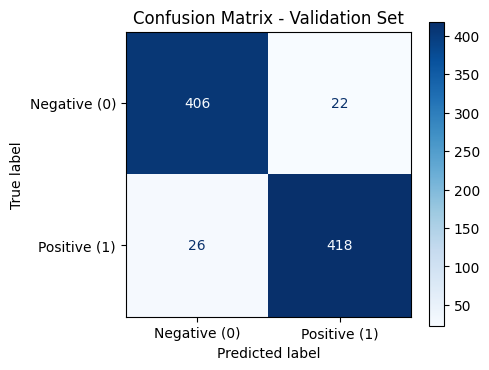

Confusion matrix saved as confusion_matrix.png


In [ ]:
# Get predictions on validation set
pred_output = trainer.predict(tokenized_dataset["validation"])
preds = pred_output.predictions.argmax(axis=-1)
labels = pred_output.label_ids

# Compute confusion matrix
cm = confusion_matrix(labels, preds, labels=[0, 1])
print("Confusion Matrix:")
print(cm)

# Extract error counts
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative (0)", "Positive (1)"])
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix - Validation Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix saved as confusion_matrix.png")


In [ ]:
# Count model parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"DeBERTa-V3-Small Total Parameters: {num_params/1e6:.1f}M")
print(f"\nModel Architecture:")
print(f"  - Number of Encoder Layers: 6")
print(f"  - Hidden Size: 768")
print(f"  - Number of Attention Heads: 12")
print(f"  - Vocabulary Size: 128,256")
print(f"  - Total Parameters: {num_params/1e6:.1f}M")


DeBERTa-V3-Small Total Parameters: 141.9M

Model Architecture:
  - Number of Encoder Layers: 6
  - Hidden Size: 768
  - Number of Attention Heads: 12
  - Vocabulary Size: 128,256
  - Total Parameters: 141.9M
